In [41]:
import tensorflow as tf
print(tf.keras.__version__)

3.13.2


In [42]:
import numpy as np

def f(x):
 return x ** 2

def gradient(x):
 return 2 * x

x = 5.0
learning_rate = 0.1

for _ in range(10):
 x -= learning_rate * gradient(x)
print(f"x: {x}, f(x): {f(x)}")

x: 0.5368709120000001, f(x): 0.2882303761517119


In [43]:
import tensorflow as tf
x = tf.Variable(5.0)

with tf.GradientTape() as tape:
 y = x ** 2
grad = tape.gradient(y, x)
print(grad.numpy())

10.0


In [44]:
import numpy as np
import tensorflow as tf
import time

size = (1000, 1000)
A = np.random.rand(*size)
B = np.random.rand(*size)

start = time.time()
C_numpy = np.dot(A, B)
print("NumPy Time:", time.time() - start)

A_tf = tf.constant(A)
B_tf = tf.constant(B)
start = time.time()
C_tf = tf.matmul(A_tf, B_tf)
print("TensorFlow Time:", time.time() - start)

NumPy Time: 0.0834343433380127
TensorFlow Time: 0.19803786277770996


In [45]:
from tensorflow.keras.layers import Dense
layer = Dense(64, activation='sigmoid')

In [46]:
x_train = np.array([[1], [2], [3], [4]])
y_train = np.array([2, 4, 6, 8])

weights = np.random.randn(1)
learning_rate = 0.01

for epoch in range(10):
    y_pred = np.dot(x_train, weights)

    loss = np.mean((y_pred - y_train) ** 2)

    gradients = 2 * np.dot(x_train.T, (y_pred - y_train)) / len(x_train)

    weights -= learning_rate * gradients

In [48]:
model.fit(x_train, y_train, epochs=10, batch_size=32)

Epoch 1/10


ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("sequential_1_1/Cast:0", shape=(None, 1), dtype=float32) with name 'keras_tensor_3' and path ''. Expected shape (None, 28, 28, 1), but input has incompatible shape (None, 1)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, 1), dtype=int64)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [49]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model = Sequential([
Dense(64, activation='relu', input_shape=(784,)),
Dense(10, activation='softmax')
])

In [50]:
learning_rate = 0.01
weights = np.random.randn(3, 3)
for _ in range(100):
gradient = np.random.randn(3, 3)
weights -= learning_rate * gradient

IndentationError: expected an indented block after 'for' statement on line 3 (742791584.py, line 4)

In [51]:
from tensorflow.keras.optimizers import SGD
optimizer = SGD(learning_rate=0.01)

In [52]:
from tensorflow.keras.layers import Dense
layer = Dense(units, activation=None, use_bias=True, kernel_initializer="glorot_uniform")

NameError: name 'units' is not defined

In [53]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
from PIL import Image # Import Pillow

In [54]:
# Define dataset paths
train_dir = "/content/drive/MyDrive/AI ML/Data/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/drive/MyDrive/AI ML/Data/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Test"

In [55]:
img_height, img_width = 28, 28

def load_images_from_folder(folder):
    images = []
    labels = []
    class_names = sorted(os.listdir(folder))
    class_map = {name: i for i, name in enumerate(class_names)}
    print(class_names)
    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)

            img = Image.open(img_path).convert("L")
            img = img.resize((img_width, img_height))
            img = np.array(img) / 255.0

            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)

x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

x_train = x_train.reshape(-1, img_height, img_width, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")


['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
Training set: (17000, 28, 28, 1), Labels: (17000, 10)
Testing set: (3000, 28, 28, 1), Labels: (3000, 10)


In [56]:
model = Sequential([
    Flatten(input_shape=(img_height, img_width, 1)),
    Dense(64, activation='sigmoid'),
    Dense(128, activation='sigmoid'),
    Dense(256, activation='sigmoid'),
    Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [57]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [58]:
callbacks = [
    ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_loss'),
    EarlyStopping(monitor='val_loss', patience=8)
]


history = model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=callbacks
)


Epoch 1/20
105/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2544 - loss: 2.0090

107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4326 - loss: 1.6594 - val_accuracy: 0.0000e+00 - val_loss: 6.7037
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8150 - loss: 0.5403 - val_accuracy: 0.0000e+00 - val_loss: 7.7090
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9029 - loss: 0.2963 - val_accuracy: 0.0000e+00 - val_loss: 8.4806
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9415 - loss: 0.2025 - val_accuracy: 0.0000e+00 - val_loss: 8.7579
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9540 - loss: 0.1543 - val_accuracy: 0.0000e+00 - val_loss: 9.0713
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9646 - loss: 0.1217 - val_accuracy: 0.0000e+00 - val_loss: 9.5733
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9715 - loss: 0.1004 - val_accuracy: 0.0000e+00 - val_loss: 9.4689
Epoch 8/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9768 - loss: 0.0827 

In [59]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")

94/94 - 0s - 3ms/step - accuracy: 0.7723 - loss: 2.0716
Test accuracy: 0.7723


In [60]:
model.save('devnagari_fcn_model.h5')

loaded_model = tf.keras.models.load_model('devnagari_fcn_model.h5')


In [61]:
predictions = model.predict(x_test)

predicted_labels = np.argmax(predictions, axis=1)

print(f"Predicted label for first image: {predicted_labels[0]}")
print(f"True label for first image: {np.argmax(y_test[0])}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted label for first image: 0
True label for first image: 0


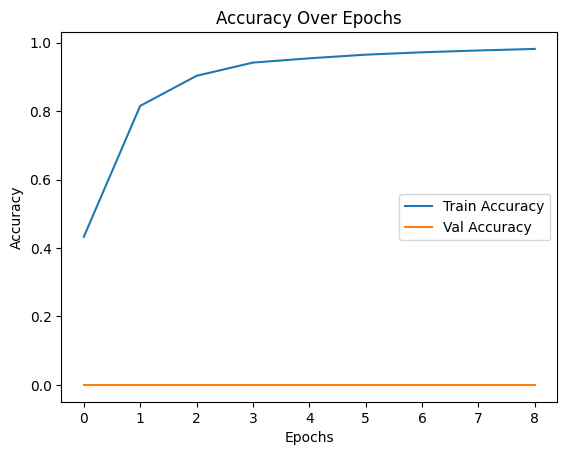

In [62]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


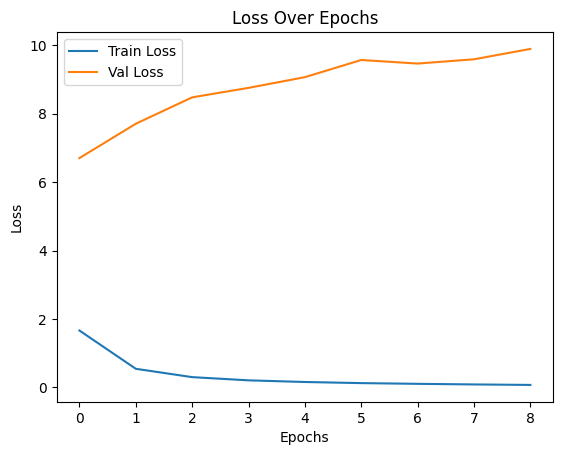

In [63]:
# Plot training & validation loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [64]:
loaded_model = tf.keras.models.load_model('devnagari_fcn_model.h5')

In [65]:
test_loss, test_acc = loaded_model.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")

94/94 - 1s - 6ms/step - accuracy: 0.7723 - loss: 2.0716
Test accuracy: 0.7723


In [66]:
predictions = loaded_model.predict(x_test)

predicted_labels = np.argmax(predictions, axis=1)

print(f"Predicted label for the first image: {predicted_labels[1]}")
print(f"True label for the first image: {np.argmax(y_test[1])}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Predicted label for the first image: 0
True label for the first image: 0
